# Introduction to Artists

A `Line2D` artist returned by a **plot()** method

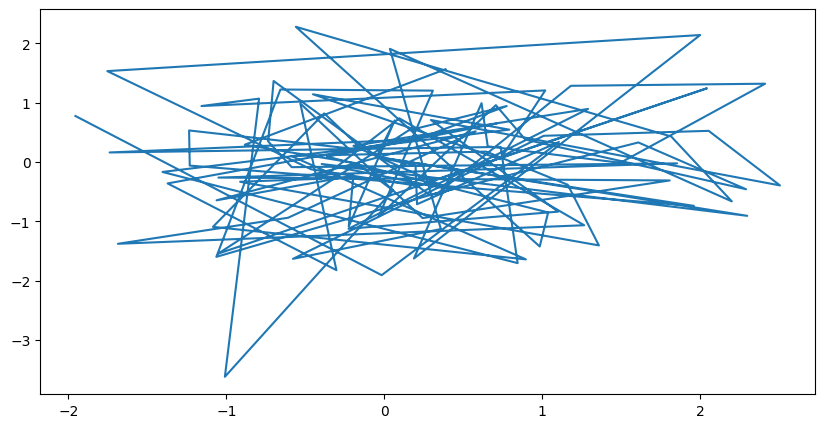

In [2]:
import matplotlib.pyplot as plt
import matplotlib.artist as martist
import numpy as np

plt.rcParams["figure.figsize"] = (10, 5)

fig, ax = plt.subplots()
x, y = np.random.randn(2, 100)
lines = ax.plot(x, y, "-", label="example")
print(lines)

plt.show()

Use `get_lines()` to retrieve the Artist.

In [3]:
print(ax.get_lines())

<a list of 1 Line2D objects>


In [4]:
print(ax.get_lines()[0])

Line2D(example)


## Changing Artist Properties

Using the `Line2D` artist, change the *linewidth* and the *color* properties of the artist

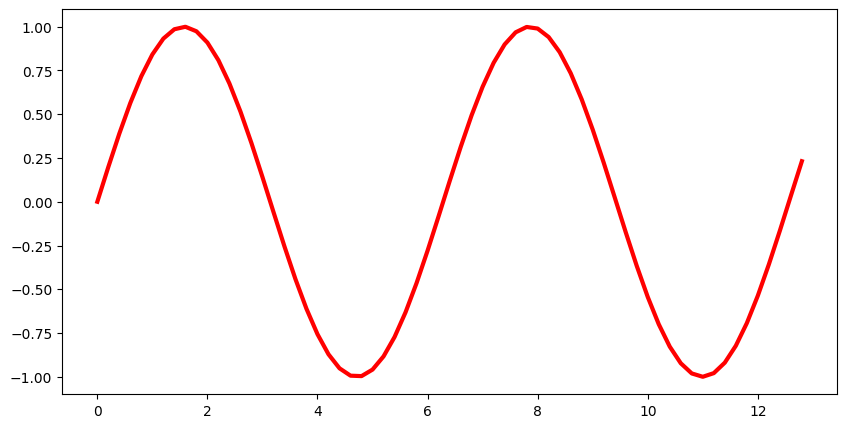

In [5]:
fig, ax = plt.subplots()
x = np.arange(0, 13, 0.2)
y = np.sin(x)
lines = ax.plot(x, y, "-", label="example", linewidth=0.2, color="blue")

lines[0].set(color="red", linewidth=3)
plt.show()

We can get all the settable properties of the artist using `getp()`

In [6]:
martist.getp(lines[0])

    agg_filter = None
    alpha = None
    animated = False
    antialiased or aa = True
    bbox = Bbox(x0=0.0, y0=-0.9999902065507035, x1=12.8, y1=0...
    children = []
    clip_box = TransformedBbox(     Bbox(x0=0.0, y0=0.0, x1=1.0, ...
    clip_on = True
    clip_path = None
    color or c = red
    dash_capstyle = butt
    dash_joinstyle = round
    data = (array([ 0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2, ...
    drawstyle or ds = default
    figure = Figure(1000x500)
    fillstyle = full
    gapcolor = None
    gid = None
    in_layout = True
    label = example
    linestyle or ls = -
    linewidth or lw = 3.0
    marker = None
    markeredgecolor or mec = red
    markeredgewidth or mew = 1.0
    markerfacecolor or mfc = red
    markerfacecoloralt or mfcalt = none
    markersize or ms = 6.0
    markevery = None
    mouseover = False
    path = Path(array([[ 0.        ,  0.        ],        [ 0...
    path_effects = []
    picker = None
    pickradius = 5
    rasterized = False


## Changing Artist Data

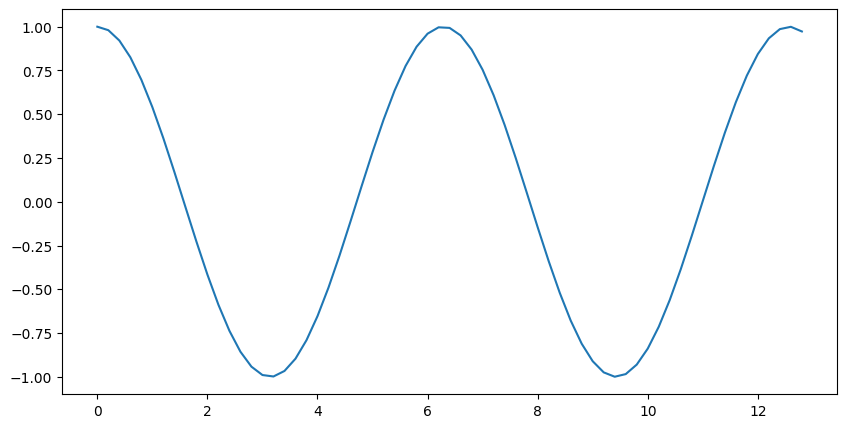

In [7]:
fig, ax = plt.subplots()
x = np.arange(0, 13, 0.2)
y = np.sin(x)
lines = ax.plot(x, y, "-", label="example")
lines[0].set_data([x, np.cos(x)])

## Manually Adding Artists

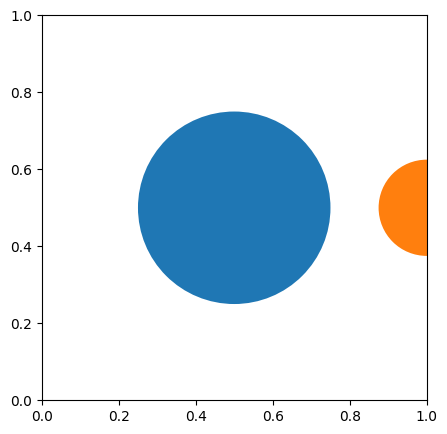

In [8]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots()
circle = mpatches.Circle((0.5, 0.5), 0.25, ec="none")
ax.add_artist(circle)

clipped_circle = mpatches.Circle((1, 0.5), 0.125, ec="none", facecolor="C1")
ax.add_artist(clipped_circle)

ax.set_aspect(1)

# Automated Color Cycle

In [9]:
from cycler import cycler

# Generate sample data: four offset sine curves
x = np.linspace(0, 2 * np.pi, 50)
offsets = np.linspace(0, 2 * np.pi, 4, endpoint=False)
yy = np.transpose([np.sin(x + phi) for phi in offsets])

print(yy.shape)
print(yy)

(50, 4)
[[ 0.00000000e+00  1.00000000e+00  1.22464680e-16 -1.00000000e+00]
 [ 1.27877162e-01  9.91790014e-01 -1.27877162e-01 -9.91790014e-01]
 [ 2.53654584e-01  9.67294863e-01 -2.53654584e-01 -9.67294863e-01]
 [ 3.75267005e-01  9.26916757e-01 -3.75267005e-01 -9.26916757e-01]
 [ 4.90717552e-01  8.71318704e-01 -4.90717552e-01 -8.71318704e-01]
 [ 5.98110530e-01  8.01413622e-01 -5.98110530e-01 -8.01413622e-01]
 [ 6.95682551e-01  7.18349350e-01 -6.95682551e-01 -7.18349350e-01]
 [ 7.81831482e-01  6.23489802e-01 -7.81831482e-01 -6.23489802e-01]
 [ 8.55142763e-01  5.18392568e-01 -8.55142763e-01 -5.18392568e-01]
 [ 9.14412623e-01  4.04783343e-01 -9.14412623e-01 -4.04783343e-01]
 [ 9.58667853e-01  2.84527587e-01 -9.58667853e-01 -2.84527587e-01]
 [ 9.87181783e-01  1.59599895e-01 -9.87181783e-01 -1.59599895e-01]
 [ 9.99486216e-01  3.20515776e-02 -9.99486216e-01 -3.20515776e-02]
 [ 9.95379113e-01 -9.60230259e-02 -9.95379113e-01  9.60230259e-02]
 [ 9.74927912e-01 -2.22520934e-01 -9.74927912e-01  2.2

In [10]:
default_cycler = cycler(color=["r", "g", "b", "y"]) + cycler(linestyle=["-", "--", ":", "-."])

plt.rc("lines", linewidth=4)
plt.rc("axes", prop_cycle=default_cycler)

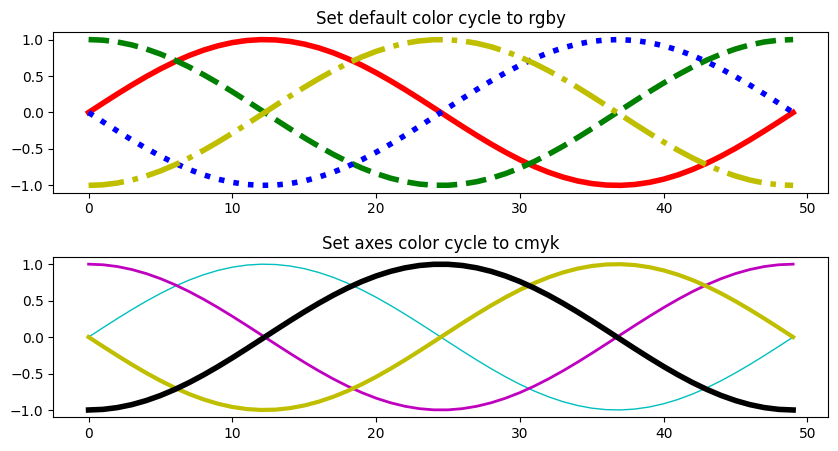

In [11]:
# fmt: off
custom_cycler = (cycler(color=["c", "m", "y", "k"]) + 
                 cycler(lw=[1, 2, 3, 4]))

fig, (ax0, ax1) = plt.subplots(nrows=2)
ax0.plot(yy)
ax0.set_title("Set default color cycle to rgby")
ax1.set_prop_cycle(custom_cycler)
ax1.plot(yy)
ax1.set_title("Set axes color cycle to cmyk")

# Add a bit more space between the two plots.
fig.subplots_adjust(hspace=0.4)
plt.show()

## Setting `prop_cycle` in the `matplotlibrc` file or style files

Use: axes.prop_cycle: cycler(color="bgrcmyk")

## Cycling through multiple properties

In [12]:
# fmt: off
cc=(cycler(color=list("rgb")) +
    cycler(linestyle=["-","--","-."]))

for d in cc:
    print(d)

{'color': 'r', 'linestyle': '-'}
{'color': 'g', 'linestyle': '--'}
{'color': 'b', 'linestyle': '-.'}


# Optimizing Artists for Performance

## Line Segment Simplification

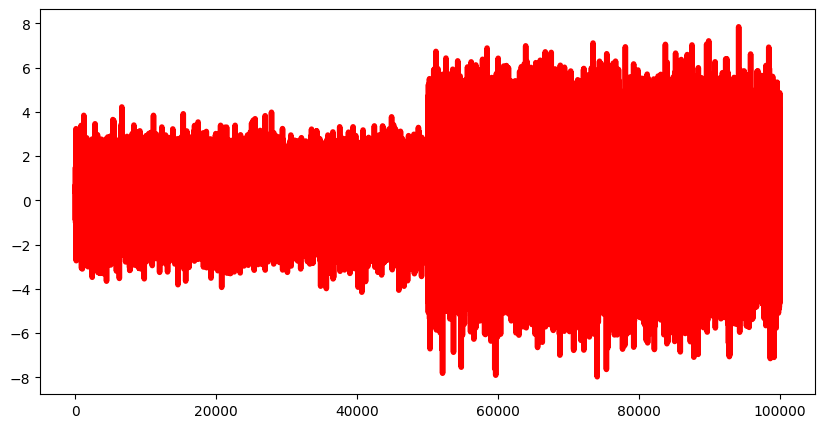

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Setup, and create the data to plot
y = np.random.randn(100_000)
y[50_000:] *= 2

# Generate 400 evenly spaced sampled starting at 10 and
# ending at 50000, on a log scale (GEOMETRIC PROGRESSION)
y[np.geomspace(10, 50_000, 400).astype(int)] = -1

# [1] Display the data without any simplification
mpl.rcParams["path.simplify"] = True
mpl.rcParams["path.simplify_threshold"] = 0.0
plt.plot(y)
plt.show()

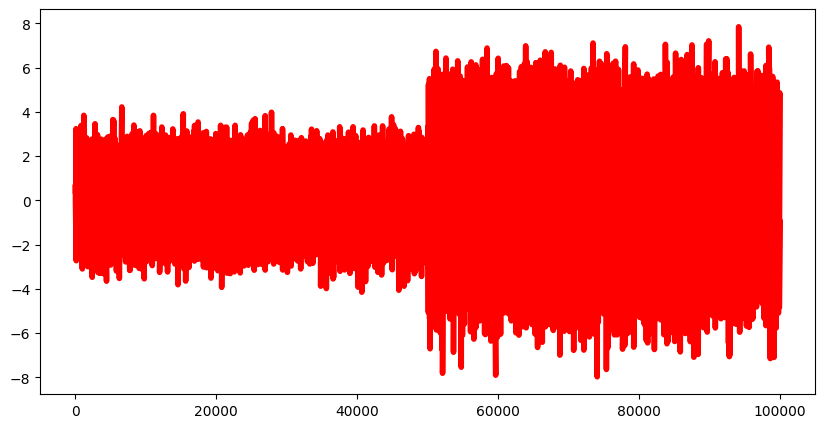

In [14]:
# [2] Display the data with simplification
mpl.rcParams["path.simplify_threshold"] = 1.0
plt.plot(y)
plt.show()

Notice the difference in rendering times above; 0.7s vs 0.1s

## Splitting Lines into Smaller Chunks

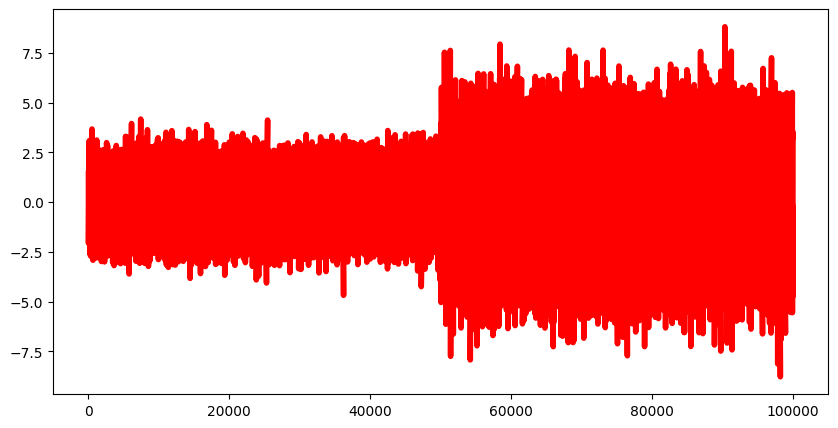

In [15]:
# Setup, and create the data to plot
y = np.random.randn(100_000)
y[50_000:] *= 2

# Generate 400 evenly spaced sampled starting at 10 and
# ending at 50000, on a log scale (GEOMETRIC PROGRESSION)
y[np.geomspace(10, 50_000, 400).astype(int)] = -1

mpl.rcParams["path.simplify"] = True
mpl.rcParams["path.simplify_threshold"] = 1.0

mpl.rcParams["agg.path.chunksize"] = 0
plt.plot(y)
plt.show()

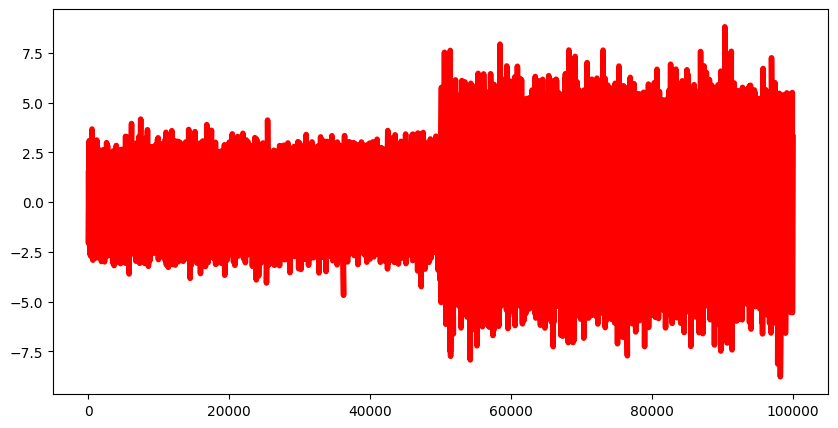

In [16]:
mpl.rcParams["agg.path.chunksize"] = 10_000
plt.plot(y)
plt.show()

# Paths

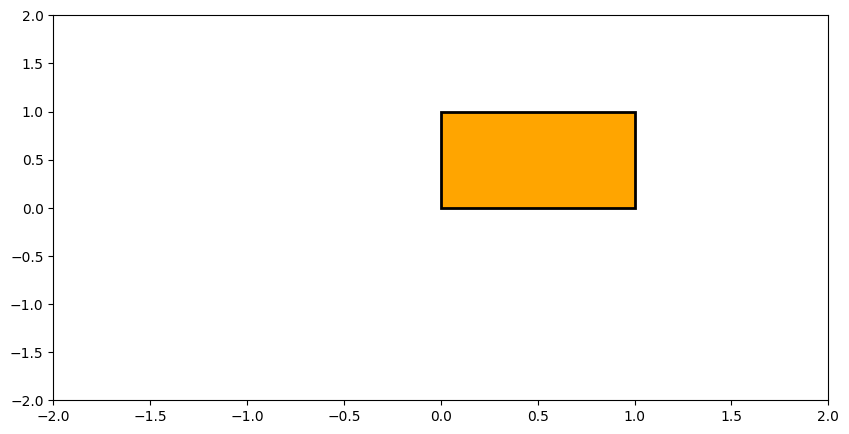

In [17]:
# Draw the unit rectangle from (0,0) to (1,1)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path

verts = [
    (0, 0),
    (0, 1),
    (1, 1),
    (1, 0),
    (0, 0),
]

codes = [
    Path.MOVETO,
    Path.LINETO,
    Path.LINETO,
    Path.LINETO,
    Path.CLOSEPOLY,
]

path = Path(verts, codes)

fig, ax = plt.subplots()
patch = patches.PathPatch(path, facecolor="orange", lw=2)
ax.add_patch(patch)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

plt.show()

## Bezier Example

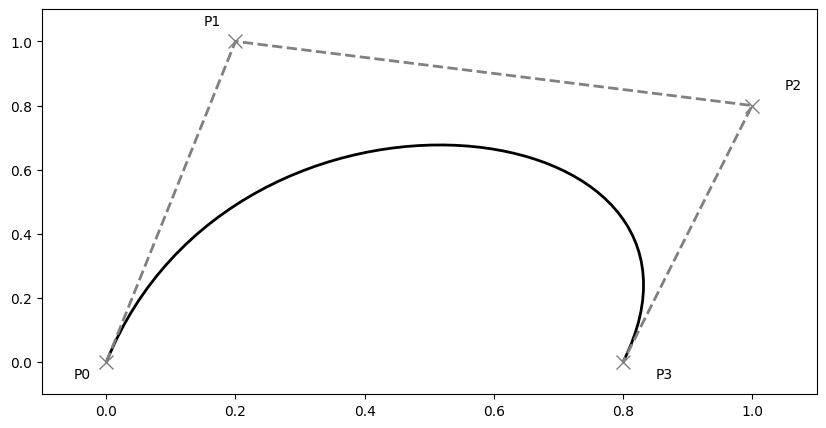

In [18]:
verts = [
    (0.0, 0.0),  # P0
    (0.2, 1.0),  # P1
    (1.0, 0.8),  # P2
    (0.8, 0.0),  # P3
]

codes = [
    Path.MOVETO,
    Path.CURVE4,
    Path.CURVE4,
    Path.CURVE4,
]

path = Path(verts, codes)

fig, ax = plt.subplots()
patch = patches.PathPatch(path, facecolor="none", lw=2)
ax.add_patch(patch)

xs, ys = zip(*verts)
ax.plot(xs, ys, "x--", lw=2, color="gray", ms=10)

ax.text(-0.05, -0.05, "P0")
ax.text(0.15, 1.05, "P1")
ax.text(1.05, 0.85, "P2")
ax.text(0.85, -0.05, "P3")

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)

plt.show()

## Compound Paths

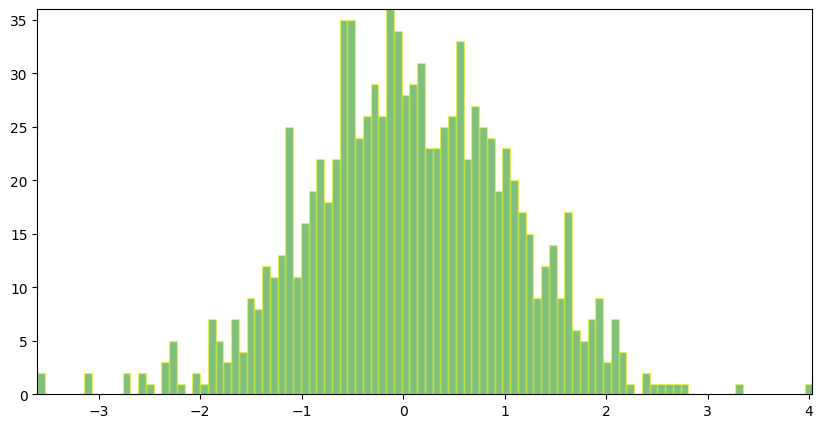

In [19]:
fig, ax = plt.subplots()

# Fixing random state for reproducibility
np.random.seed(19680801)

# histogram our data with numpy
data = np.random.randn(1000)

# returns n    : array with the values of the histogram
#         bins : array with the bin edges
n, bins = np.histogram(data, 100)

# get the corners of the rectangles for the histogram
left = np.array(bins[:-1])
right = np.array(bins[1:])
bottom = np.zeros(len(left))
top = bottom + n
nrects = len(left)

nverts = nrects * (1 + 3 + 1)
verts = np.zeros((nverts, 2))
codes = np.full(nverts, Path.LINETO, dtype=int)
codes[0::5] = Path.MOVETO
codes[4::5] = Path.CLOSEPOLY
verts[0::5, 0] = left
verts[0::5, 1] = bottom
verts[1::5, 0] = left
verts[1::5, 1] = top
verts[2::5, 0] = right
verts[2::5, 1] = top
verts[3::5, 0] = right
verts[3::5, 1] = bottom

barpath = Path(verts, codes)
patch = patches.PathPatch(barpath, facecolor="green", edgecolor="yellow", alpha=0.5)
ax.add_patch(patch)

ax.set_xlim(left[0], right[-1])
ax.set_ylim(bottom.min(), top.max())

plt.show()

# Path Effects Guide

The simplest path effect is the `Normal` effect: simply draw the artist without any effect

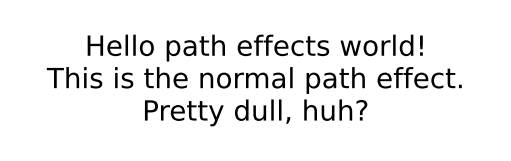

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

fig, ax = plt.subplots(figsize=(5, 1.5), layout="constrained")
text = ax.text(
    0.5,
    0.5,
    "Hello path effects world!\nThis is the normal " "path effect.\nPretty dull, huh?",
    ha="center",
    va="center",
    size=20,
)
text.set_path_effects([path_effects.Normal()])
ax.set_frame_on(False)
ax.set_xticks([])
ax.set_yticks([])

plt.show()

## Adding a Shadow

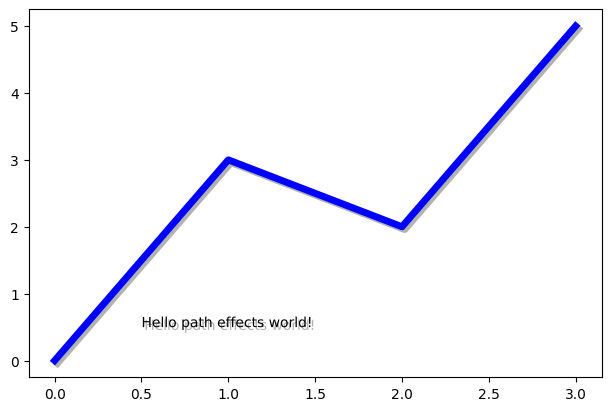

In [21]:
import matplotlib.patheffects as path_effects

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")

ax.text(
    0.5,
    0.5,
    "Hello path effects world!",
    path_effects=[path_effects.withSimplePatchShadow()],
)

ax.plot(
    [0, 3, 2, 5],
    linewidth=5,
    color="blue",
    path_effects=[
        path_effects.SimpleLineShadow(),
        path_effects.Normal(),
    ],
)

## Making an Artist Stand Out

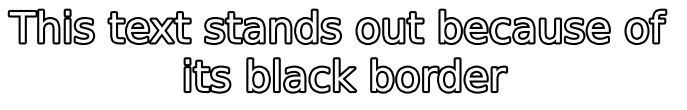

In [22]:
# Draw an outline in a bold color, below the actual artist
fig, ax = plt.subplots(figsize=(7, 1), layout="constrained")

text = ax.text(
    0.5,
    0.5,
    "This text stands out because of \nits black border",
    color="white",
    ha="center",
    va="center",
    size=30,
)
text.set_path_effects(
    [
        path_effects.Stroke(linewidth=3, foreground="black"),
        path_effects.Normal(),
    ],
)

ax.set_frame_on(False)
ax.set_xticks([])
ax.set_yticks([])

plt.show()

## Greater Control of the Path Effect Artist

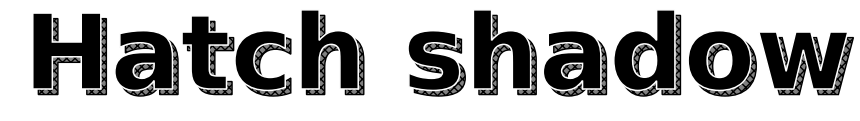

In [23]:
fig, ax = plt.subplots(figsize=(8.5, 1), layout="constrained")

t = ax.text(
    0.02,
    0.5,
    "Hatch shadow",
    fontsize=75,
    weight=1000,
    va="center",
)

t.set_path_effects(
    [
        path_effects.PathPatchEffect(
            offset=(4, -4),
            hatch="xxxx",
            facecolor="gray",
        ),
        path_effects.PathPatchEffect(
            edgecolor="white",
            linewidth=1.1,
            facecolor="black",
        ),
    ]
)

ax.set_frame_on(False)
ax.set_xticks([])
ax.set_yticks([])

plt.show()

# The `extent` keyword argument of imshow

# Transformations Tutorial

<dl>
    <dt style='font-weight:bold;color:green;'>ax.transData</dt>
    <dd>Convert the values from data coordinates, to display coordinates</dd>
    <dt style='font-weight:bold;color:green;'>ax.transAxes</dt>
    <dd>
        Convert values from Axes coordinates, to display coordinates.<br/>
        In Axes coordinates, (0,0) is bottom left and (1,1) top right.
    </dd>  
    <dt style='font-weight:bold;color:green;'>fig.transFigure</dt>  
    <dd>
        Convert values from Figure coordinates, to display coordinates.<br/>
        In Figure coordinates, (0,0) is bottom left and (1,1) top right.
    </dd> 
</dl>

## Data Coordinates

Stretch the data limits from 0 to 10, on the x-axis and from -1 to 1 on the y-axis.

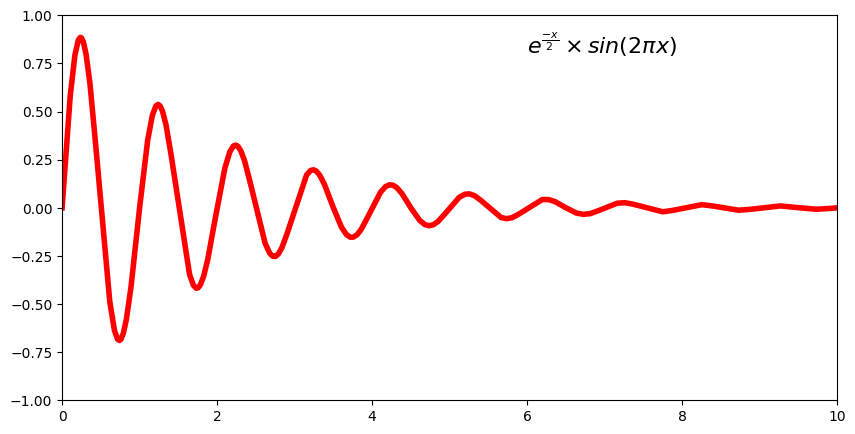

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

x = np.arange(0, 10, 0.005)
y = np.exp(-x / 2.0) * np.sin(2 * np.pi * x)

fig, ax = plt.subplots()

ax.plot(x, y)
ax.set_xlim(0, 10)
ax.set_ylim(-1, 1)
ax.text(x=0.6, y=0.9, s=r"$e^\frac{-x}{2} \times sin(2 \pi x)$", transform=ax.transAxes, fontsize=16)

plt.show()

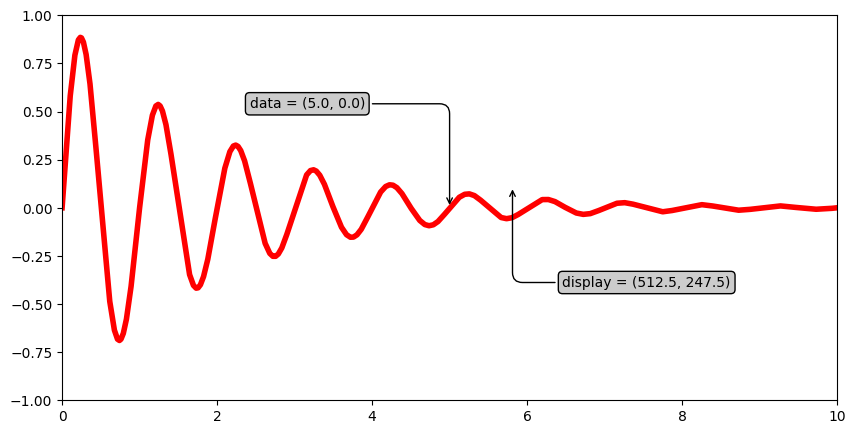

In [25]:
x = np.arange(0, 10, 0.005)
y = np.exp(-x / 2.0) * np.sin(2 * np.pi * x)

fig, ax = plt.subplots()

ax.plot(x, y)
ax.set_xlim(0, 10)
ax.set_ylim(-1, 1)

xdata, ydata = 5, 0
xdisplay, ydisplay = ax.transData.transform((xdata, ydata))
bbox = dict(boxstyle="round", fc="0.8")
arrowprops = dict(arrowstyle="->", connectionstyle="angle,angleA=0,angleB=90,rad=10")
offset = 72

ax.annotate(
    f"data = ({xdata:.1f}, {ydata:.1f})",
    (xdata, ydata),
    xytext=(-2 * offset, offset),
    textcoords="offset points",
    bbox=bbox,
    arrowprops=arrowprops,
)

ax.annotate(
    f"display = ({xdisplay:.1f}, {ydisplay:.1f})",
    (xdisplay, ydisplay),
    xytext=(0.5 * offset, -offset),
    xycoords="figure pixels",
    textcoords="offset points",
    bbox=bbox,
    arrowprops=arrowprops,
)

plt.show()

## Axes Coordinates

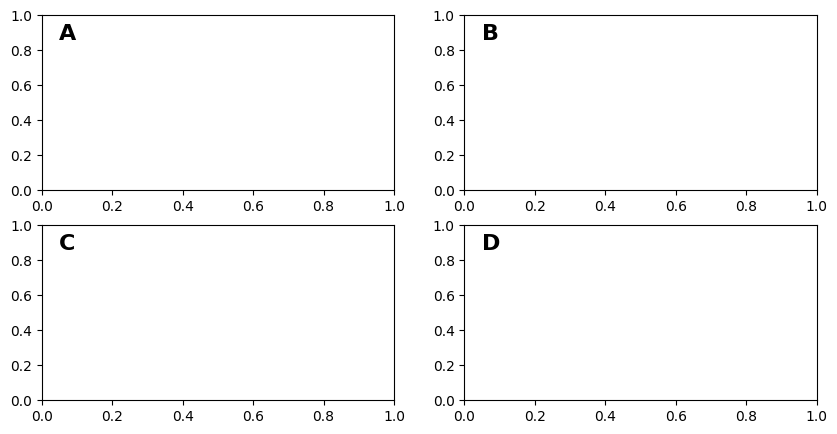

In [ ]:
fig = plt.figure()

for i, label in enumerate(("A", "B", "C", "D")):
    ax = fig.add_subplot(2, 2, i + 1)
    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=16, fontweight="bold", va="top")

plt.show()

Plot some random dots in data space, with an overlay of a semi-transparent `Circle` centered in the middle of the Axes.

Changing the data `xlim` and `ylim`, the data move but <span style="text-decoration:underline;">the Circle remains fixed</span> because it's not in data coordinates.

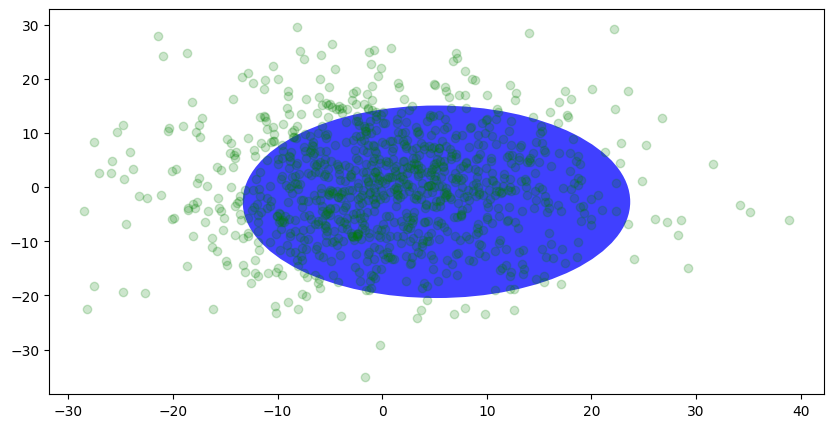

In [35]:
fig, ax = plt.subplots()
x, y = 10 * np.random.randn(2, 1000)
ax.plot(x, y, "go", alpha=0.2)  # plot some data in data coordinates
circ = mpatches.Circle((0.5, 0.5), 0.25, transform=ax.transAxes, facecolor="blue", alpha=0.75)
ax.add_patch(circ)

plt.show()

## Blended Transformations

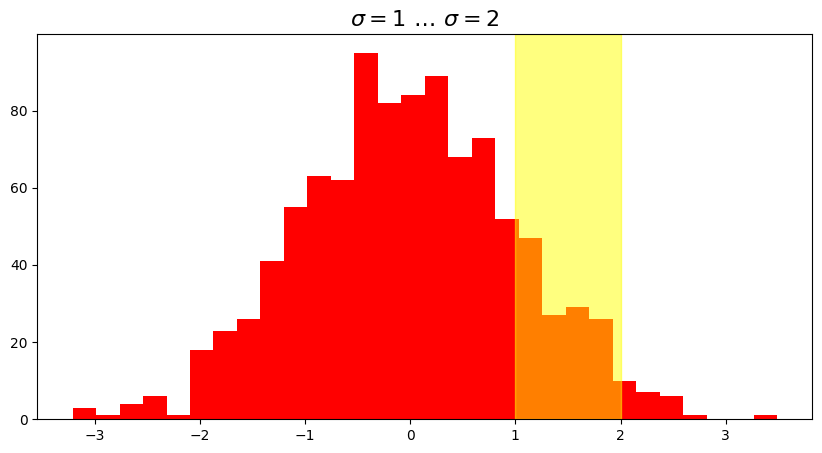

In [ ]:
import matplotlib.transforms as transforms

fig, ax = plt.subplots()
x = np.random.randn(1000)

ax.hist(x, 30)
ax.set_title(r"$\sigma=1 \/ \dots \/ \sigma=2$", fontsize=16)

# The x coord of this transformation are data, and the y coord are axes
trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)

# Highlight the 1..2 stddev region with a span.
# We want x to be in data coordinates and y to span from 0..1 in axes coordinates.
rect = mpatches.Rectangle((1, 0), width=1, height=1, transform=trans, color="yellow", alpha=0.5)
ax.add_patch(rect)


plt.show()

## Plotting in Physical Coordinates

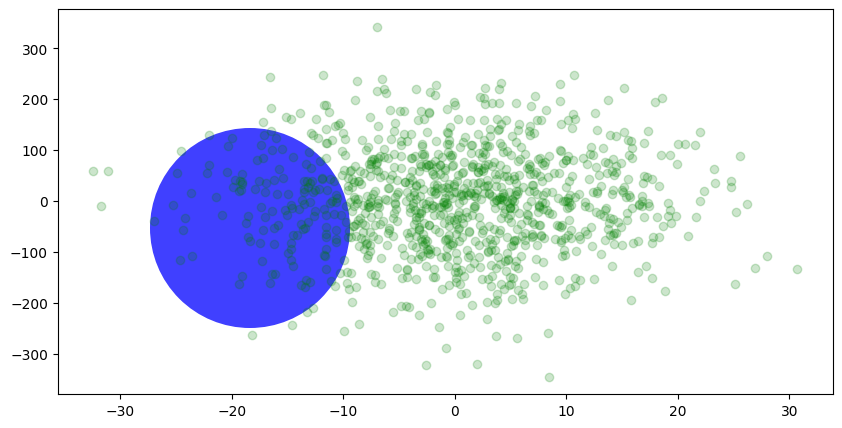

In [45]:
fig, ax = plt.subplots()
x, y = 10 * np.random.randn(2, 1000)
ax.plot(x, y * 10, "go", alpha=0.2)  # plot some data in data coordinates
# add a circle in fixed coordinates
circ = mpatches.Circle((2.5, 2), 1, transform=fig.dpi_scale_trans, facecolor="blue", alpha=0.75)
ax.add_patch(circ)

plt.show()

## Using Offset Transforms to Create a Shadow Effect

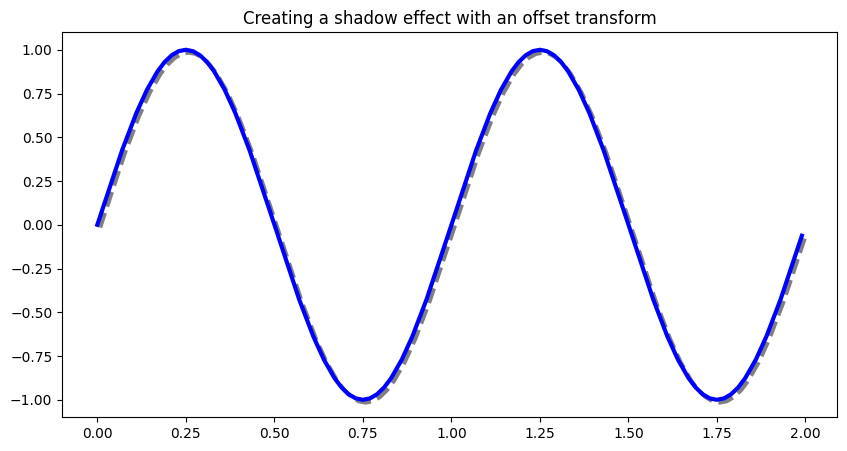

In [52]:
fig, ax = plt.subplots()

# make a simple sin wave
x = np.arange(0, 2, 0.01)
y = np.sin(2 * np.pi * x)
(line,) = ax.plot(x, y, lw=3, c="blue")

# shift the object over 2 points, and down 2 points
dx, dy = 2 / 72, -2 / 72  # 1 pt = 1/72 inches
offset = transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)
shadow_transform = ax.transData + offset

# now plot the same data with our offset transform
# use the z-order to make sure we are below the line
ax.plot(x, y, lw=3, c="gray", transform=shadow_transform, zorder=0.5 * line.get_zorder())
ax.set_title("Creating a shadow effect with an offset transform")

plt.show()